The following additional libraries are needed to run this
notebook. Note that running on Colab is experimental, please report a Github
issue if you have any problem.

In [ ]:
!pip install d2l==1.0.3


# Naive Bayes
:label:`sec_naive_bayes`

Throughout the previous sections, we learned about the theory of probability and random variables.  To put this theory to work, let's introduce the *naive Bayes* classifier.  This uses nothing but probabilistic fundamentals to allow us to perform classification of digits.

Learning is all about making assumptions. If we want to classify a new data example that we have never seen before we have to make some assumptions about which data examples are similar to each other. The naive Bayes classifier, a popular and remarkably clear algorithm, assumes all features are independent from each other to simplify the computation. In this section, we will apply this model to recognize characters in images.


In [1]:
from mpl_toolkits import mplot3d
import torch
import torchvision
from IPython import display
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Set the rendering format to high-resolution SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## Optical Character Recognition

MNIST :cite:`LeCun.Bottou.Bengio.ea.1998` is one of widely used datasets. It contains 60,000 images for training and 10,000 images for validation. Each image contains a handwritten digit from 0 to 9. The task is classifying each image into the corresponding digit.

Gluon provides a `MNIST` class in the `data.vision` module to
automatically retrieve the dataset from the Internet.
Subsequently, Gluon will use the already-downloaded local copy.
We specify whether we are requesting the training set or the test set
by setting the value of the parameter `train` to `True` or `False`, respectively.
Each image is a grayscale image with both width and height of $28$ with shape ($28$,$28$,$1$). We use a customized transformation to remove the last channel dimension. In addition, the dataset represents each pixel by an unsigned $8$-bit integer.  We quantize them into binary features to simplify the problem.


In [10]:
data_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    lambda x: torch.floor(x * 255 / 128).squeeze(dim=0)
])

mnist_train = torchvision.datasets.MNIST(
    root='temp', train=True, transform=data_transform, download=True)
mnist_test = torchvision.datasets.MNIST(
    root='temp', train=False, transform=data_transform, download=True)

We can access a particular example, which contains the image and the corresponding label.


In [12]:
image, label = mnist_train[2]
image.shape, label, len(mnist_train)

(torch.Size([28, 28]), 4, 60000)

Our example, stored here in the variable `image`, corresponds to an image with a height and width of $28$ pixels.


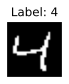

In [4]:
plt.figure(figsize=(1, 1))  # width, height in inches

# 2. Plot the image using a grayscale colormap
plt.imshow(image.numpy(), cmap='gray')

# 3. Add the label as the title
plt.title(f"Label: {label}")

# 4. Hide the axis ticks for a cleaner look
plt.axis('off')

# 5. Display the plot
plt.show()

In [5]:
image.shape, image.dtype

(torch.Size([28, 28]), torch.float32)

Our code stores the label of each image as a scalar. Its type is a $32$-bit integer.


In [6]:
label, type(label)

(4, int)

We can also access multiple examples at the same time.


In [7]:
images = torch.stack([mnist_train[i][0] for i in range(10, 38)], dim=0)
labels = torch.tensor([mnist_train[i][1] for i in range(10, 38)])
images.shape, labels.shape

(torch.Size([28, 28, 28]), torch.Size([28]))

Let's visualize these examples.


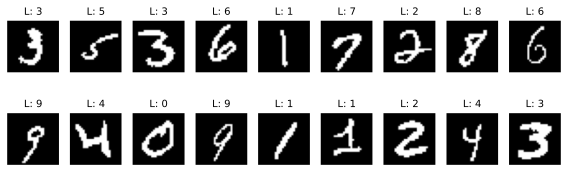

In [8]:
# d2l.show_images(images, 2, 9);
def show_images(images, labels=None, nrows: 'int' = 1, ncols: 'int' = 1):
    fig, axes = plt.subplots(nrows=2, ncols=9, figsize=(8, 3))
    axes = axes.flatten()
    
    for i in range(18):
        axes[i].imshow(images[i].numpy(), cmap='gray')
        # Add the text label above each digit
        axes[i].set_title(f"L: {labels[i].item()}", fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_images(images, labels)

## The Probabilistic Model for Classification

In a classification task, we map an example into a category. Here an example is a grayscale $28\times 28$ image, and a category is a digit. (Refer to :numref:`sec_softmax` for a more detailed explanation.)
One natural way to express the classification task is via the probabilistic question: what is the most likely label given the features (i.e., image pixels)? Denote by $\mathbf x\in\mathbb R^d$ the features of the example and $y\in\mathbb R$ the label. Here features are image pixels, where we can reshape a $2$-dimensional image to a vector so that $d=28^2=784$, and labels are digits.
The probability of the label given the features is $p(y  \mid  \mathbf{x})$. If we are able to compute these probabilities, which are $p(y  \mid  \mathbf{x})$ for $y=0, \ldots,9$ in our example, then the classifier will output the prediction $\hat{y}$ given by the expression:

$$\hat{y} = \mathrm{argmax} \> p(y  \mid  \mathbf{x}).$$

Unfortunately, this requires that we estimate $p(y  \mid  \mathbf{x})$ for every value of $\mathbf{x} = x_1, ..., x_d$. Imagine that each feature could take one of $2$ values. For example, the feature $x_1 = 1$ might signify that the word apple appears in a given document and $x_1 = 0$ would signify that it does not. If we had $30$ such binary features, that would mean that we need to be prepared to classify any of $2^{30}$ (over 1 billion!) possible values of the input vector $\mathbf{x}$.

Moreover, where is the learning? If we need to see every single possible example in order to predict the corresponding label then we are not really learning a pattern but just memorizing the dataset.

## The Naive Bayes Classifier

Fortunately, by making some assumptions about conditional independence, we can introduce some inductive bias and build a model capable of generalizing from a comparatively modest selection of training examples. To begin, let's use Bayes theorem, to express the classifier as

$$\hat{y} = \mathrm{argmax}_y \> p(y  \mid  \mathbf{x}) = \mathrm{argmax}_y \> \frac{p( \mathbf{x}  \mid  y) p(y)}{p(\mathbf{x})}.$$

Note that the denominator is the normalizing term $p(\mathbf{x})$ which does not depend on the value of the label $y$. As a result, we only need to worry about comparing the numerator across different values of $y$. Even if calculating the denominator turned out to be intractable, we could get away with ignoring it, so long as we could evaluate the numerator. Fortunately, even if we wanted to recover the normalizing constant, we could.  We can always recover the normalization term since $\sum_y p(y  \mid  \mathbf{x}) = 1$.

Now, let's focus on $p( \mathbf{x}  \mid  y)$. Using the chain rule of probability, we can express the term $p( \mathbf{x}  \mid  y)$ as

$$p(x_1  \mid y) \cdot p(x_2  \mid  x_1, y) \cdot ... \cdot p( x_d  \mid  x_1, ..., x_{d-1}, y).$$

By itself, this expression does not get us any further. We still must estimate roughly $2^d$ parameters. However, if we assume that *the features are conditionally independent of each other, given the label*, then suddenly we are in much better shape, as this term simplifies to $\prod_i p(x_i  \mid  y)$, giving us the predictor

$$\hat{y} = \mathrm{argmax}_y \> \prod_{i=1}^d p(x_i  \mid  y) p(y).$$

If we can estimate $p(x_i=1  \mid  y)$ for every $i$ and $y$, and save its value in $P_{xy}[i, y]$, here $P_{xy}$ is a $d\times n$ matrix with $n$ being the number of classes and $y\in\{1, \ldots, n\}$, then we can also use this to estimate $p(x_i = 0 \mid y)$, i.e.,

$$
p(x_i = t_i \mid y) =
\begin{cases}
    P_{xy}[i, y] & \textrm{for } t_i=1 ;\\
    1 - P_{xy}[i, y] & \textrm{for } t_i = 0 .
\end{cases}
$$

In addition, we estimate $p(y)$ for every $y$ and save it in $P_y[y]$, with $P_y$ a $n$-length vector. Then, for any new example $\mathbf t = (t_1, t_2, \ldots, t_d)$, we could compute

$$\begin{aligned}\hat{y} &= \mathrm{argmax}_ y \ p(y)\prod_{i=1}^d   p(x_t = t_i \mid y) \\ &= \mathrm{argmax}_y \ P_y[y]\prod_{i=1}^d \ P_{xy}[i, y]^{t_i}\, \left(1 - P_{xy}[i, y]\right)^{1-t_i}\end{aligned}$$
:eqlabel:`eq_naive_bayes_estimation`

for any $y$. So our assumption of conditional independence has taken the complexity of our model from an exponential dependence on the number of features $\mathcal{O}(2^dn)$ to a linear dependence, which is $\mathcal{O}(dn)$.


## Training

The problem now is that we do not know $P_{xy}$ and $P_y$. So we need to estimate their values given some training data first. This is *training* the model. Estimating $P_y$ is not too hard. Since we are only dealing with $10$ classes, we may count the number of occurrences $n_y$ for each of the digits and divide it by the total amount of data $n$. For instance, if digit 8 occurs $n_8 = 5,800$ times and we have a total of $n = 60,000$ images, the probability estimate is $p(y=8) = 0.0967$.


In [9]:
X = torch.stack([mnist_train[i][0] for i in range(len(mnist_train))], dim=0)
Y = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

n_y = torch.zeros(10)
for y in range(10):
    # count number of images of each category
    n_y[y] = (Y == y).sum()
P_y = n_y / n_y.sum()
P_y, n_y

(tensor([0.0987, 0.1124, 0.0993, 0.1022, 0.0974, 0.0904, 0.0986, 0.1044, 0.0975,
         0.0992]),
 tensor([5923., 6742., 5958., 6131., 5842., 5421., 5918., 6265., 5851., 5949.]))

Now on to slightly more difficult things $P_{xy}$. Since we picked black and white images, $p(x_i  \mid  y)$ denotes the probability that pixel $i$ is switched on for class $y$. Just like before we can go and count the number of times $n_{iy}$ such that an event occurs and divide it by the total number of occurrences of $y$, i.e., $n_y$. But there is something slightly troubling: certain pixels may never be black (e.g., for well cropped images the corner pixels might always be white). A convenient way for statisticians to deal with this problem is to add pseudo counts to all occurrences. Hence, rather than $n_{iy}$ we use $n_{iy}+1$ and instead of $n_y$ we use $n_{y}+2$ (since there are two possible values pixel $i$ can take - it can either be black or white). This is also called *Laplace Smoothing*.  It may seem ad-hoc, however it can be motivated from a Bayesian point-of-view by a Beta-binomial model.


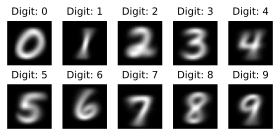

In [24]:
n_x = torch.zeros((10, 28, 28))
for y in range(10):
    n_x[y] = torch.tensor(X.numpy()[Y.numpy() == y].sum(axis=0))
P_xy = (n_x + 1) / (n_y + 2).reshape(10, 1, 1)

# 1. Initialize a 2x5 grid of axes (for the 10 digit classes)
num_rows = 2
num_cols = 5
fig, axes = plt.subplots(num_rows, num_cols, figsize=(4, 2))

# 2. Flatten the 2D grid matrix into a 1D list to easily loop over
axes = axes.flatten()

# 3. Iterate over the 10 digit classes
for y in range(10):
    # Select the 28x28 probability matrix for digit y
    # .detach().cpu().numpy() guarantees compatibility regardless of CPU/GPU device context
    img_prob = P_xy[y].detach().cpu().numpy()
    
    # Display the pixel probabilities map
    axes[y].imshow(img_prob, cmap='gray')
    
    # Label each image subplot with its corresponding digit index
    axes[y].set_title(f"Digit: {y}", fontsize=10)
    
    # Turn off the coordinate axis ticks
    axes[y].axis('off')

# 4. Clean up sub-plot padding bounds and render the plot
plt.tight_layout()
plt.show()

By visualizing these $10\times 28\times 28$ probabilities (for each pixel for each class) we could get some mean looking digits.

Now we can use :eqref:`eq_naive_bayes_estimation` to predict a new image. Given $\mathbf x$, the following functions computes $p(\mathbf x \mid y)p(y)$ for every $y$.


In [11]:
def bayes_pred(x):
    x = x.unsqueeze(0)  # (28, 28) -> (1, 28, 28)
    p_xy = P_xy * x + (1 - P_xy)*(1 - x)
    p_xy = p_xy.reshape(10, -1).prod(dim=1)  # p(x|y)
    return p_xy * P_y

image, label = mnist_test[0]
bayes_pred(image)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

This went horribly wrong! To find out why, let's look at the per pixel probabilities. They are typically numbers between $0.001$ and $1$. We are multiplying $784$ of them. At this point it is worth mentioning that we are calculating these numbers on a computer, hence with a fixed range for the exponent. What happens is that we experience *numerical underflow*, i.e., multiplying all the small numbers leads to something even smaller until it is rounded down to zero.  We discussed this as a theoretical issue in :numref:`sec_maximum_likelihood`, but we see the phenomena clearly here in practice.

As discussed in that section, we fix this by use the fact that $\log a b = \log a + \log b$, i.e., we switch to summing logarithms.
Even if both $a$ and $b$ are small numbers, the logarithm values should be in a proper range.


In [13]:
import math

a = 0.1
print('underflow:', a**784)
print('logarithm is normal:', 784*math.log(a))

underflow: 0.0
logarithm is normal: -1805.2267129073316


Since the logarithm is an increasing function, we can rewrite :eqref:`eq_naive_bayes_estimation` as

$$ \hat{y} = \mathrm{argmax}_y \ \log P_y[y] + \sum_{i=1}^d \Big[t_i\log P_{xy}[x_i, y] + (1-t_i) \log (1 - P_{xy}[x_i, y]) \Big].$$

We can implement the following stable version:


In [29]:
log_P_xy = torch.log(P_xy)
log_P_xy_neg = torch.log(1 - P_xy)
log_P_y = torch.log(P_y)

def bayes_pred_stable(x):
    x = x.unsqueeze(0)  # (28, 28) -> (1, 28, 28)
    p_xy = log_P_xy * x + log_P_xy_neg * (1 - x)
    p_xy = p_xy.reshape(10, -1).sum(axis=1)  # p(x|y)
    return p_xy + log_P_y

py = bayes_pred_stable(image)
py

tensor([-360.1054, -495.6628, -306.0663, -308.6743, -231.6172, -308.3254,
        -362.6828, -287.2021, -334.3552, -274.5800])

We may now check if the prediction is correct.


In [30]:
py.argmax(dim=0)

tensor(4)

In [15]:
py.argmax(dim=0) == label

tensor(True)

If we now predict a few validation examples, we can see the Bayes
classifier works pretty well.


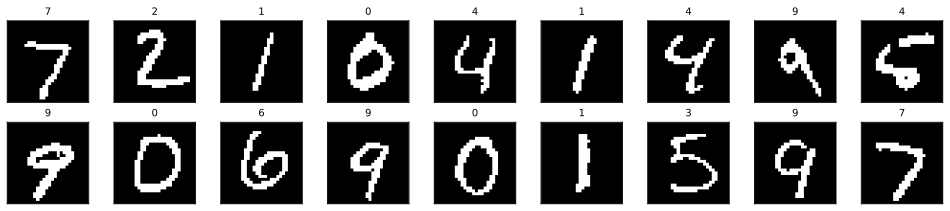

In [19]:
def predict(X):
    return [bayes_pred_stable(x).argmax(dim=0).type(torch.int32).item()
            for x in X]

X = torch.stack([mnist_test[i][0] for i in range(18)], dim=0)
y = torch.tensor([mnist_test[i][1] for i in range(18)])
preds = predict(X)
#d2l.show_images(X, 2, 9, titles=[str(d) for d in preds]);

def show_images(images, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images using matplotlib."""
    figsize = (num_cols * scale, num_rows * scale)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, (ax, img) in enumerate(zip(axes, images)):
        # Convert PyTorch tensor to NumPy
        if hasattr(img, 'numpy'):
            img = img.numpy()
            
        # If PyTorch format (C, H, W), transpose to Matplotlib format (H, W, C)
        if img.ndim == 3 and img.shape[0]: 
            img = img.transpose(1, 2, 0)
        
        # Squeeze grayscale images from (H, W, 1) to (H, W)
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img.squeeze(-1)
            ax.imshow(img, cmap='gray')
        elif img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
            
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10)
            
    plt.tight_layout()
    plt.show()

# Run it again with your inputs:
show_images(X, 2, 9, titles=[str(d) for d in preds])



Finally, let's compute the overall accuracy of the classifier.


In [20]:
X = torch.stack([mnist_test[i][0] for i in range(len(mnist_test))], dim=0)
y = torch.tensor([mnist_test[i][1] for i in range(len(mnist_test))])
preds = torch.tensor(predict(X), dtype=torch.int32)
float((preds == y).sum()) / len(y)  # Validation accuracy

0.8427

Modern deep networks achieve error rates of less than $0.01$. The relatively poor performance is due to the incorrect statistical assumptions that we made in our model: we assumed that each and every pixel are *independently* generated, depending only on the label. This is clearly not how humans write digits, and this wrong assumption led to the downfall of our overly naive (Bayes) classifier.

## Summary
* Using Bayes' rule, a classifier can be made by assuming all observed features are independent.
* This classifier can be trained on a dataset by counting the number of occurrences of combinations of labels and pixel values.
* This classifier was the gold standard for decades for tasks such as spam detection.

## Exercises
1. Consider the dataset $[[0,0], [0,1], [1,0], [1,1]]$ with labels given by the XOR of the two elements $[0,1,1,0]$.  What are the probabilities for a Naive Bayes classifier built on this dataset.  Does it successfully classify our points?  If not, what assumptions are violated?
1. Suppose that we did not use Laplace smoothing when estimating probabilities and a data example arrived at testing time which contained a value never observed in training.  What would the model output?
1. The naive Bayes classifier is a specific example of a Bayesian network, where the dependence of random variables are encoded with a graph structure.  While the full theory is beyond the scope of this section (see :citet:`Koller.Friedman.2009` for full details), explain why allowing explicit dependence between the two input variables in the XOR model allows for the creation of a successful classifier.


[Discussions](https://discuss.d2l.ai/t/1100)


In [2]:
import random
#mock_data = [(torch.randint(0, 256, (2, 2)), i) for i in range(2)]
#mock_data = mock_data + [(torch.randint(0, 256, (2, 2)), i) for i in range(2)]
mock_data = [(torch.rand(2, 2), i) for i in range(2)]
mock_data = mock_data + [(torch.rand(2, 2), i) for i in range(2)]
mock_data_test = [(torch.randint(0, 256, (2, 2)), i) for i in range(2)]
s_img, label = mock_data[3]
s_img, label

(tensor([[0.5162, 0.1973],
         [0.2533, 0.0106]]),
 1)

In [3]:
X = torch.stack([mock_data[i][0] for i in range(len(mock_data))], dim=0)
Y = torch.tensor([mock_data[i][1] for i in range(len(mock_data))])

In [4]:
X, Y

(tensor([[[0.2798, 0.7422],
          [0.6710, 0.4479]],
 
         [[0.0084, 0.2745],
          [0.6582, 0.8269]],
 
         [[0.6938, 0.0670],
          [0.0495, 0.6948]],
 
         [[0.5162, 0.1973],
          [0.2533, 0.0106]]]),
 tensor([0, 1, 0, 1]))

In [5]:
n_y = torch.zeros(2)
for y in range(2):
    # count of images with 0 or 1 which is 1 each of 0 and 1
    n_y[y] = (Y == y).sum() 
P_y = n_y / n_y.sum()
# we have total of two so value is 1 / 2 = 0.5
P_y, n_y

(tensor([0.5000, 0.5000]), tensor([2., 2.]))

In [6]:
n_x = torch.zeros((2, 2, 2))
for y in range(2):
    n_x[y] = torch.tensor(X.numpy()[Y.numpy() == y].sum(axis=0))
P_xy = (n_x + 1) / (n_y + 2).reshape(2, 1, 1)
n_x, (n_y+2).reshape(2, 1, 1), P_xy


(tensor([[[0.9736, 0.8092],
          [0.7205, 1.1428]],
 
         [[0.5246, 0.4718],
          [0.9115, 0.8375]]]),
 tensor([[[4.]],
 
         [[4.]]]),
 tensor([[[0.4934, 0.4523],
          [0.4301, 0.5357]],
 
         [[0.3812, 0.3680],
          [0.4779, 0.4594]]]))

In [7]:
log_P_xy = torch.log(P_xy)
log_P_xy_neg = torch.log(1 - P_xy)
log_P_y = torch.log(P_y)

def bayes_pred_stable(x):
    x = x.unsqueeze(0)  # (2, 2) -> (1, 2, 2)
    p_xy = log_P_xy * x + log_P_xy_neg * (1 - x)
    p_xy = p_xy.reshape(2, -1).sum(axis=1)  # p(x|y)
    return p_xy + log_P_y

image, label = mock_data[0]
py = bayes_pred_stable(image)
py, log_P_xy, log_P_xy_neg, log_P_y, image.unsqueeze(0), 1 - P_xy, torch.log(1 - P_xy)

(tensor([-3.5789, -3.5662]),
 tensor([[[-0.7064, -0.7934],
          [-0.8437, -0.6242]],
 
         [[-0.9645, -0.9998],
          [-0.7384, -0.7779]]]),
 tensor([[[-0.6800, -0.6020],
          [-0.5623, -0.7672]],
 
         [[-0.4799, -0.4588],
          [-0.6498, -0.6150]]]),
 tensor([-0.6931, -0.6931]),
 tensor([[[0.2798, 0.7422],
          [0.6710, 0.4479]]]),
 tensor([[[0.5066, 0.5477],
          [0.5699, 0.4643]],
 
         [[0.6188, 0.6320],
          [0.5221, 0.5406]]]),
 tensor([[[-0.6800, -0.6020],
          [-0.5623, -0.7672]],
 
         [[-0.4799, -0.4588],
          [-0.6498, -0.6150]]]))

In [8]:
py.argmax(dim=0) == label

tensor(False)

# Naive Bayes, Simply - Notes

## The core idea
Naive Bayes answers one question: **given the evidence I see, which category is most likely?**

It is built on Bayes' theorem:

**P(category | evidence) ∝ P(category) × P(evidence | category)**

In plain words: *how common is the category overall* × *how typical is this evidence for that category*.

## Why "Naive"?
When there are multiple pieces of evidence (e.g., several words in an email), it assumes each one is **independent** of the others, given the category. That's rarely true in real life (the words "free" and "offer" often appear together), but it makes the math very simple, and it still works surprisingly well.

## Example: Spam or not spam?

Suppose we've looked at 100 past emails:

- 40 were **spam**, 60 were **not spam** (ham)
- The word **"free"** appeared in 30 of the 40 spam emails and 6 of the 60 ham emails
- The word **"meeting"** appeared in 8 of the 40 spam emails and 30 of the 60 ham emails

A new email arrives containing both **"free"** and **"meeting"**. Is it spam?

**Step 1: Prior (how common is each class?)**
- P(spam) = 40/100 = 0.4
- P(ham) = 60/100 = 0.6

**Step 2: Likelihoods (how typical is each word for each class?)**

| | Spam | Ham |
|---|---|---|
| P(free \| class) | 30/40 = 0.75 | 6/60 = 0.10 |
| P(meeting \| class) | 8/40 = 0.20 | 30/60 = 0.50 |

**Step 3: Multiply (this is where the "naive" independence assumption is used)**
- Spam score = 0.4 × 0.75 × 0.20 = **0.06**
- Ham score = 0.6 × 0.10 × 0.50 = **0.03**

**Step 4: Normalize to get probabilities**
- P(spam) = 0.06 / (0.06 + 0.03) = **67%**
- P(ham) = 0.03 / 0.09 = **33%**

**Prediction: spam.** "Free" was a strong spam signal and outweighed the ham signal from "meeting".

## Training is just counting
There's no complex optimization. Training means counting how often each feature appears in each class. That's why Naive Bayes is fast, works with small datasets, and is a great first baseline.

## Two practical gotchas
1. **Zero probabilities:** if a word never appeared in spam during training, its probability is 0, and the whole product becomes 0. The fix is *Laplace smoothing*: add 1 to every count so nothing is ever exactly zero.
2. **Many features:** multiplying lots of small numbers underflows, so real implementations add *log* probabilities instead.

## Where it's used
Spam filtering, sentiment analysis, document/topic classification, and quick baselines for text problems.

If you want to try it hands-on, scikit-learn's `MultinomialNB` lets you build this spam classifier in about 10 lines. Want me to walk through that next?